# Notebook 2 — PTB-XL Dataset
**Dataset:** `datasets/khyeh0719/ptb-xl-dataset` — large 12-lead ECG dataset  
**Recordings:** ~21,800 records | 12 leads | 100 Hz (low-res) → 1000 timesteps  
**Task:** NORM (healthy, label=0) vs. Confirmed Cardiac Disease (label=1). Ambiguous records dropped.  
**Models:** LTC (proper Hasani 2021) · CTRNN · Neural ODE (RK4) · CT-GRU  
**Metrics:** 12 per model


In [1]:
!pip install wfdb -q
import os, ast, math
import numpy as np
import pandas as pd
import wfdb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix,
    precision_score, recall_score, matthews_corrcoef,
    cohen_kappa_score, average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 3.6 MB/s eta 0:00:0000:01
Device: cuda


In [2]:
# ─── CONFIG ────────────────────────────────────────────────────────────────
DATA_PATH  = ("/kaggle/input/datasets/khyeh0719/ptb-xl-dataset/"
              "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/")
BATCH_SIZE = 32
EPOCHS     = 30
LR         = 1e-3
HIDDEN     = 64
ODE_STEPS  = 6
SEED       = 42
INPUT_SIZE = 12   # 12 leads
SEQ_LEN    = 1000 # 100 Hz × 10 s

torch.manual_seed(SEED)
np.random.seed(SEED)


In [3]:
# ─── LABEL STRATEGY — NORM vs confirmed cardiac disease ──────────────────────
# Ambiguous records (neither purely NORM nor confirmed disease) are dropped.
CD_CODES = {
    'MI','STTC','STEMI','NSTEMI','AMI','OLD_MI',
    'LBBB','RBBB','IRBBB','ILBBB','CRBBB','CLBBB',
    'AF','AFL','SVT','SVTAC','PSVT','VT','VFL','VF',
    'HYP','LVH','RVH','LAO_LAE','RAO_RAE',
    'ISCAL','ISCAN','ISCIL','ISCIN','ISCLA','ISC_',
}

def make_label(scp_dict):
    codes = set(scp_dict.keys())
    if 'NORM' in codes and not codes.intersection(CD_CODES): return 0
    if codes.intersection(CD_CODES):                          return 1
    return -1  # ambiguous

df = pd.read_csv(DATA_PATH + "ptbxl_database.csv")
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)
df['label']     = df['scp_codes'].apply(make_label)
df = df[df['label'] != -1].reset_index(drop=True)
print(f"Samples after filtering: {len(df)}")
print(df['label'].value_counts())


Samples after filtering: 14953
label
0    9276
1    5677
Name: count, dtype: int64


In [4]:
# ─── SPLITS — use PTB-XL's recommended stratified folds ─────────────────────
train_df = df[df['strat_fold'] <= 8].reset_index(drop=True)
val_df   = df[df['strat_fold'] == 9].reset_index(drop=True)
test_df  = df[df['strat_fold'] == 10].reset_index(drop=True)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


Train: 11935 | Val: 1506 | Test: 1512


In [5]:
# ─── DATASET ────────────────────────────────────────────────────────────────
class PTBXLDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        x, _ = wfdb.rdsamp(DATA_PATH + row['filename_lr'])
        x    = x.astype(np.float32)            # (1000, 12)
        # per-lead z-score normalisation
        x    = (x - x.mean(axis=0)) / (x.std(axis=0) + 1e-8)
        return (torch.tensor(x, dtype=torch.float32),
                torch.tensor(row['label'], dtype=torch.float32))


def make_loader(df, shuffle):
    return DataLoader(PTBXLDataset(df), batch_size=BATCH_SIZE,
                      shuffle=shuffle, num_workers=2, pin_memory=True)

train_loader = make_loader(train_df, shuffle=True)
val_loader   = make_loader(val_df,   shuffle=False)
test_loader  = make_loader(test_df,  shuffle=False)

# Weighted loss to handle class imbalance
n_pos  = int(train_df['label'].sum())
n_neg  = len(train_df) - n_pos
pos_w  = torch.tensor([n_neg/(n_pos+1e-8)], dtype=torch.float32).to(DEVICE)
print(f"pos_weight: {pos_w.item():.3f}  (n_neg={n_neg}, n_pos={n_pos})")


pos_weight: 1.633  (n_neg=7403, n_pos=4532)


In [6]:
# ─── 12-METRIC EVALUATOR ────────────────────────────────────────────────────
def compute_12_metrics(labels, preds, probs):
    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0,1]).ravel()
    sens  = tp / (tp+fn+1e-8)
    spec  = tn / (tn+fp+1e-8)
    prec  = tp / (tp+fp+1e-8)
    npv   = tn / (tn+fn+1e-8)
    f1    = 2*prec*sens / (prec+sens+1e-8)
    f2    = 5*prec*sens / (4*prec+sens+1e-8)
    acc   = (tp+tn) / (tp+tn+fp+fn+1e-8)
    bal   = (sens+spec) / 2
    mcc   = matthews_corrcoef(labels, preds)
    kappa = cohen_kappa_score(labels, preds)
    auc   = roc_auc_score(labels, probs)
    ap    = average_precision_score(labels, probs)
    return dict(Accuracy=acc, Sensitivity=sens, Specificity=spec,
                Precision=prec, NPV=npv, F1=f1, F2=f2,
                BalancedAcc=bal, MCC=mcc, Kappa=kappa,
                ROC_AUC=auc, PR_AUC=ap)

def print_metrics(m, name):
    print(f"\n{'='*55}\n  {name}\n{'='*55}")
    for k, v in m.items(): print(f"  {k:<18}: {v:.4f}")


In [7]:
# ─── TRAINING / EVAL HELPERS ────────────────────────────────────────────────
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    for x, y in loader:
        x       = x.to(DEVICE)
        logits  = model(x)
        probs   = torch.sigmoid(logits).cpu().numpy()
        preds   = (probs > 0.5).astype(int)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(y.numpy().astype(int))
    return all_labels, all_preds, all_probs

def run_training(model, model_name, train_loader, test_loader, criterion,
                 clip_fn=None, epochs=EPOCHS, patience=7):
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-5)

    best_auc, best_state, wait = 0.0, None, 0

    for epoch in range(1, epochs+1):
        model.train(); total = 0; nan_batches = 0
        for i, (x, y) in enumerate(train_loader):
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            logits = model(x)

            # ── NaN guard ───────────────────────────────────────────────────
            if torch.isnan(logits).any():
                nan_batches += 1
                optimizer.zero_grad()   # skip this batch entirely
                continue

            loss = criterion(logits, y)

            if torch.isnan(loss):
                nan_batches += 1
                optimizer.zero_grad()
                continue

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)  # tighter: was 1.0
            optimizer.step()
            if clip_fn: clip_fn()      # clamp biophysical params after every step
            total += loss.item()

            if i % 100 == 0:
                print(f"  Epoch {epoch} | Batch {i}/{len(train_loader)} | Loss: {loss.item():.4f}")

        if nan_batches > 0:
            print(f"  ⚠ Skipped {nan_batches} NaN batches this epoch")

        scheduler.step()
        lbls, preds, probs = evaluate(model, test_loader)

        # ── NaN guard for probs before roc_auc_score ────────────────────────
        if any(np.isnan(p) for p in probs):
            print(f"Epoch {epoch:3d}/{epochs} | NaN in predictions — skipping AUC")
            continue

        auc = roc_auc_score(lbls, probs)
        n_batches = len(train_loader) - nan_batches
        avg_loss  = total / max(n_batches, 1)
        print(f"Epoch {epoch:3d}/{epochs} | AvgLoss: {avg_loss:.4f} | AUC: {auc:.4f}")

        if auc > best_auc:
            best_auc   = auc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0; print(f"  ✓ Best AUC: {best_auc:.4f}")
        else:
            wait += 1
            if wait >= patience: print("  Early stopping."); break

    model.load_state_dict(best_state)
    lbls, preds, probs = evaluate(model, test_loader)
    metrics = compute_12_metrics(lbls, preds, probs)
    print_metrics(metrics, model_name)
    return metrics, lbls, preds, probs


In [8]:
# ─── CONFUSION MATRIX PLOT ──────────────────────────────────────────────────
def plot_cm(labels, preds, title):
    cm = confusion_matrix(labels, preds, labels=[0,1])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
    plt.xlabel("Predicted Label"); plt.ylabel("True Label"); plt.title(title)
    plt.xticks([0.5,1.5],["Negative (NORM)","Positive (Disease)"])
    plt.yticks([0.5,1.5],["Negative (NORM)","Positive (Disease)"], rotation=0)
    plt.tight_layout(); plt.show()
    return cm


yet to run 19/4/2026

## Model 1 — Proper LTC (Hasani et al. 2021)

In [9]:
# ─── FASTER LTC — PTB-XL OPTIMISED ─────────────────────────────────────────

# ── Update config ────────────────────────────────────────────────────────────
HIDDEN      = 32
ODE_STEPS   = 3
DOWNSAMPLE  = 4
SEQ_LEN_DS  = 1000 // DOWNSAMPLE
LR_LTC = 3e-4


# ── Updated Dataset with downsampling ────────────────────────────────────────
class PTBXLDatasetFast(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        x, _ = wfdb.rdsamp(DATA_PATH + row['filename_lr'])
        x    = x.astype(np.float32)               # (1000, 12)
        x    = x[::DOWNSAMPLE, :]                  # (250, 12) — downsample
        x    = (x - x.mean(axis=0)) / (x.std(axis=0) + 1e-8)
        return (torch.tensor(x, dtype=torch.float32),
                torch.tensor(row['label'], dtype=torch.float32))


train_loader = DataLoader(PTBXLDatasetFast(train_df), batch_size=64,
                          shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(PTBXLDatasetFast(val_df),   batch_size=64,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(PTBXLDatasetFast(test_df),  batch_size=64,
                          shuffle=False, num_workers=2, pin_memory=True)


# ── Faster LTC Cell ───────────────────────────────────────────────────────────
class LTCCellFast(nn.Module):
    def __init__(self, input_size, hidden_size, ode_steps=3):
        super().__init__()
        self.hidden_size = hidden_size
        self.ode_steps   = ode_steps
        self.register_buffer('dt', torch.tensor(1.0 / ode_steps))

        # Sensory: use Linear layers instead of raw parameter broadcasting
        # This is equivalent but uses cuBLAS kernels → much faster on GPU
        self.sensory_W     = nn.Parameter(torch.rand(input_size, hidden_size) * 0.5)
        self.sensory_erev  = nn.Parameter((torch.randint(0,2,(input_size,hidden_size)).float()*2-1))
        self.sensory_mu    = nn.Parameter(torch.rand(input_size, hidden_size) * 0.5 + 0.3)
        self.sensory_sigma = nn.Parameter(torch.rand(input_size, hidden_size) * 5.0 + 3.0)

        self.W     = nn.Parameter(torch.rand(hidden_size, hidden_size) * 0.5)
        self.erev  = nn.Parameter((torch.randint(0,2,(hidden_size,hidden_size)).float()*2-1))
        self.mu    = nn.Parameter(torch.rand(hidden_size, hidden_size) * 0.5 + 0.3)
        self.sigma = nn.Parameter(torch.rand(hidden_size, hidden_size) * 5.0 + 3.0)

        self.vleak   = nn.Parameter(torch.zeros(hidden_size))
        self.gleak   = nn.Parameter(torch.ones(hidden_size))
        self.cm      = nn.Parameter(torch.ones(hidden_size) * 0.5)
        self.tau_min = nn.Parameter(torch.ones(hidden_size) * 0.1)
        self.A_tau   = nn.Parameter(torch.randn(hidden_size) * 0.1)
        self.B_tau   = nn.Parameter(torch.randn(hidden_size) * 0.1)
        self.b_tau   = nn.Parameter(torch.zeros(hidden_size))

    def _sig(self, x, sigma): return torch.sigmoid(sigma * x)

    def precompute_sensory(self, x_seq):
        """
        Precompute sensory gates for ALL timesteps at once — vectorised.
        x_seq: (batch, seq_len, input_size)
        returns s_num, s_den: each (batch, seq_len, hidden_size)
        """
        # (batch, seq_len, input_size, 1) - (1, 1, input_size, hidden_size)
        x_exp  = x_seq.unsqueeze(-1)                          # (B, T, I, 1)
        s_gate = self._sig(x_exp - self.sensory_mu,
                           self.sensory_sigma)                 # (B, T, I, H)
        W_abs  = torch.abs(self.sensory_W)                    # (I, H)
        s_num  = (W_abs * s_gate * self.sensory_erev).sum(2)  # (B, T, H)
        s_den  = (W_abs * s_gate).sum(2)                      # (B, T, H)
        return s_num, s_den

    def forward(self, x_seq):
        """
        x_seq: (batch, seq_len, input_size)  — full sequence at once
        """
        B, T, _ = x_seq.shape

        # Precompute sensory contribution for all timesteps (1 GPU call)
        s_num, s_den = self.precompute_sensory(x_seq)  # (B, T, H) each
        x_agg = x_seq.mean(dim=2, keepdim=True)        # (B, T, 1) for tau

        v_t = torch.zeros(B, self.hidden_size, device=x_seq.device)

        for t in range(T):
            sn = s_num[:, t, :]    # (B, H)
            sd = s_den[:, t, :]    # (B, H)
            xa = x_agg[:, t, :]   # (B, 1)

            for _ in range(self.ode_steps):
                v_exp  = v_t.unsqueeze(2)                          # (B, H, 1)
                r_gate = self._sig(v_exp - self.mu, self.sigma)    # (B, H, H)
                W_abs  = torch.abs(self.W)
                r_num  = (W_abs * r_gate * self.erev).sum(1)       # (B, H)
                r_den  = (W_abs * r_gate).sum(1)                   # (B, H)

                v_inf = (self.gleak * self.vleak + r_num + sn) / \
                        (self.gleak + r_den + sd + 1e-8)

                tau  = torch.abs(self.tau_min) + \
                       nn.functional.softplus(
                           self.A_tau * xa + self.B_tau * v_t + self.b_tau)

                v_t = v_t + self.dt * (v_inf - v_t) * \
                      (torch.abs(self.cm) / (tau + 1e-8))

        return v_t

    def clip_parameters(self):
        with torch.no_grad():
            self.cm.clamp_(1e-4, 100.)
            self.gleak.clamp_(1e-5, 100.)
            self.tau_min.clamp_(1e-4, 10.)


class LTCClassifierFast(nn.Module):
    def __init__(self, input_size=12, hidden_size=HIDDEN,
                 ode_steps=ODE_STEPS, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell    = LTCCellFast(input_size, hidden_size, ode_steps)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # Pass full sequence — cell handles the time loop internally
        v = self.cell(x)
        return self.fc(self.dropout(v)).squeeze(-1)   # raw logits

    def clip_parameters(self): self.cell.clip_parameters()


ltc_model = LTCClassifierFast().to(DEVICE)
crit_ltc  = nn.BCEWithLogitsLoss(pos_weight=pos_w)
print(f"LTC params: {sum(p.numel() for p in ltc_model.parameters() if p.requires_grad):,}")
LR_BACKUP = LR
LR = LR_LTC
ltc_metrics, ltc_lbls, ltc_preds, ltc_probs = run_training(
    ltc_model, "LTC — PTB-XL (Fast)",
    train_loader, test_loader, crit_ltc,
    clip_fn=ltc_model.clip_parameters)

LR = LR_BACKUP

LTC params: 5,889
  Epoch 1 | Batch 0/187 | Loss: 0.8434
  Epoch 1 | Batch 100/187 | Loss: 0.8433
Epoch   1/30 | AvgLoss: 0.8589 | AUC: 0.6039
  ✓ Best AUC: 0.6039
  Epoch 2 | Batch 0/187 | Loss: 0.7944
  Epoch 2 | Batch 100/187 | Loss: 0.8485
Epoch   2/30 | AvgLoss: 0.8545 | AUC: 0.6311
  ✓ Best AUC: 0.6311
  Epoch 3 | Batch 0/187 | Loss: 0.8723
  Epoch 3 | Batch 100/187 | Loss: 0.8095
Epoch   3/30 | AvgLoss: 0.8474 | AUC: 0.6510
  ✓ Best AUC: 0.6510
  Epoch 4 | Batch 0/187 | Loss: 0.8553
  Epoch 4 | Batch 100/187 | Loss: 0.8597
Epoch   4/30 | AvgLoss: 0.8337 | AUC: 0.6841
  ✓ Best AUC: 0.6841
  Epoch 5 | Batch 0/187 | Loss: 0.7835
  Epoch 5 | Batch 100/187 | Loss: 0.7953
Epoch   5/30 | AvgLoss: 0.7878 | AUC: 0.7438
  ✓ Best AUC: 0.7438
  Epoch 6 | Batch 0/187 | Loss: 0.8753
  Epoch 6 | Batch 100/187 | Loss: 0.6343
Epoch   6/30 | AvgLoss: 0.7086 | AUC: 0.7854
  ✓ Best AUC: 0.7854
  Epoch 7 | Batch 0/187 | Loss: 0.7248
  Epoch 7 | Batch 100/187 | Loss: 0.6637
Epoch   7/30 | AvgLoss: 0.

## Model 2 — CTRNN

In [10]:
INPUT_SIZE = 12  #12 leads
SEQ_LEN    = 1000 // DOWNSAMPLE

class CTRNNClassifier(nn.Module):
    def __init__(self, input_size=INPUT_SIZE, hidden_size=HIDDEN,
                 ode_steps=3, dt=0.1, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.ode_steps   = ode_steps
        self.dt          = dt
        self.W_in  = nn.Linear(input_size, hidden_size, bias=False)
        self.W_rec = nn.Linear(hidden_size, hidden_size)
        self._tau  = nn.Parameter(torch.ones(hidden_size))
        self.drop  = nn.Dropout(dropout)
        self.fc    = nn.Linear(hidden_size, 1)

    @property
    def tau(self): return nn.functional.softplus(self._tau) + 1e-4

    def forward(self, x):
        h = torch.zeros(x.shape[0], self.hidden_size, device=x.device)
        for t in range(x.shape[1]):
            xt = x[:,t,:]
            for _ in range(self.ode_steps):
                h = h + self.dt*(-h/self.tau + torch.tanh(self.W_in(xt)+self.W_rec(h)))
        return self.fc(self.drop(h)).squeeze(-1)


ctrnn_model = CTRNNClassifier().to(DEVICE)
crit_ctrnn  = nn.BCEWithLogitsLoss(pos_weight=pos_w)
print(f"CTRNN params: {sum(p.numel() for p in ctrnn_model.parameters() if p.requires_grad):,}")

ctrnn_metrics, ctrnn_lbls, ctrnn_preds, ctrnn_probs = run_training(
    ctrnn_model, "CTRNN — PTB-XL", train_loader, test_loader, crit_ctrnn)


CTRNN params: 1,505
  Epoch 1 | Batch 0/187 | Loss: 0.8824
  Epoch 1 | Batch 100/187 | Loss: 0.8023
Epoch   1/30 | AvgLoss: 0.8227 | AUC: 0.7218
  ✓ Best AUC: 0.7218
  Epoch 2 | Batch 0/187 | Loss: 0.9375
  Epoch 2 | Batch 100/187 | Loss: 0.7175
Epoch   2/30 | AvgLoss: 0.6877 | AUC: 0.8435
  ✓ Best AUC: 0.8435
  Epoch 3 | Batch 0/187 | Loss: 0.5604
  Epoch 3 | Batch 100/187 | Loss: 0.6155
Epoch   3/30 | AvgLoss: 0.5817 | AUC: 0.8641
  ✓ Best AUC: 0.8641
  Epoch 4 | Batch 0/187 | Loss: 0.4817
  Epoch 4 | Batch 100/187 | Loss: 0.5854
Epoch   4/30 | AvgLoss: 0.5483 | AUC: 0.8757
  ✓ Best AUC: 0.8757
  Epoch 5 | Batch 0/187 | Loss: 0.4107
  Epoch 5 | Batch 100/187 | Loss: 0.5982
Epoch   5/30 | AvgLoss: 0.5118 | AUC: 0.8858
  ✓ Best AUC: 0.8858
  Epoch 6 | Batch 0/187 | Loss: 0.5403
  Epoch 6 | Batch 100/187 | Loss: 0.6122
Epoch   6/30 | AvgLoss: 0.4815 | AUC: 0.8809
  Epoch 7 | Batch 0/187 | Loss: 0.5890
  Epoch 7 | Batch 100/187 | Loss: 0.4790
Epoch   7/30 | AvgLoss: 0.4800 | AUC: 0.8693


## Model 3 — Neural ODE (RK4)

In [11]:
class NODEClassifier(nn.Module):
    def __init__(self, input_size=INPUT_SIZE, hidden_size=HIDDEN,
                 ode_steps=2, dt=0.1, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.ode_steps   = ode_steps
        self.dt          = dt
        self.W   = nn.Linear(input_size+hidden_size, hidden_size)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size, 1)

    def _f(self, x, h): return torch.tanh(self.W(torch.cat([x,h],dim=-1)))

    def forward(self, x):
        h = torch.zeros(x.shape[0], self.hidden_size, device=x.device)
        dt = self.dt
        for t in range(x.shape[1]):
            xt = x[:,t,:]
            for _ in range(self.ode_steps):
                k1 = dt*self._f(xt,h)
                k2 = dt*self._f(xt,h+0.5*k1)
                k3 = dt*self._f(xt,h+0.5*k2)
                k4 = dt*self._f(xt,h+k3)
                h  = h + (k1+2*k2+2*k3+k4)/6.0
        return self.fc(self.drop(h)).squeeze(-1)


node_model = NODEClassifier().to(DEVICE)
crit_node  = nn.BCEWithLogitsLoss(pos_weight=pos_w)
print(f"NODE params: {sum(p.numel() for p in node_model.parameters() if p.requires_grad):,}")

node_metrics, node_lbls, node_preds, node_probs = run_training(
    node_model, "NODE — PTB-XL", train_loader, test_loader, crit_node)


NODE params: 1,473
  Epoch 1 | Batch 0/187 | Loss: 16.2360
  Epoch 1 | Batch 100/187 | Loss: 4.5379
Epoch   1/30 | AvgLoss: 4.8013 | AUC: 0.5130
  ✓ Best AUC: 0.5130
  Epoch 2 | Batch 0/187 | Loss: 1.7198
  Epoch 2 | Batch 100/187 | Loss: 0.8667
Epoch   2/30 | AvgLoss: 0.9230 | AUC: 0.6052
  ✓ Best AUC: 0.6052
  Epoch 3 | Batch 0/187 | Loss: 0.8973
  Epoch 3 | Batch 100/187 | Loss: 0.8380
Epoch   3/30 | AvgLoss: 0.8633 | AUC: 0.6087
  ✓ Best AUC: 0.6087
  Epoch 4 | Batch 0/187 | Loss: 1.0531
  Epoch 4 | Batch 100/187 | Loss: 0.8293
Epoch   4/30 | AvgLoss: 0.8555 | AUC: 0.6275
  ✓ Best AUC: 0.6275
  Epoch 5 | Batch 0/187 | Loss: 0.9030
  Epoch 5 | Batch 100/187 | Loss: 0.7752
Epoch   5/30 | AvgLoss: 0.8334 | AUC: 0.7022
  ✓ Best AUC: 0.7022
  Epoch 6 | Batch 0/187 | Loss: 0.6332
  Epoch 6 | Batch 100/187 | Loss: 0.8817
Epoch   6/30 | AvgLoss: 0.7577 | AUC: 0.7673
  ✓ Best AUC: 0.7673
  Epoch 7 | Batch 0/187 | Loss: 0.6016
  Epoch 7 | Batch 100/187 | Loss: 0.7803
Epoch   7/30 | AvgLoss: 

## Model 4 — CT-GRU (Mozer 2017)

In [12]:
class CTGRUClassifier(nn.Module):
    def __init__(self, input_size=INPUT_SIZE, hidden_size=HIDDEN, M=4, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.M           = M
        ln_tau = np.array([np.log(10.**(0.5*i)) for i in range(M)], dtype=np.float32)
        self.register_buffer('ln_tau', torch.tensor(ln_tau).view(1,1,M))
        self.register_buffer('decay',
            torch.tensor(np.exp(-1./np.exp(ln_tau)).astype(np.float32)).view(1,1,M))
        fused = input_size + hidden_size
        mid   = float(np.log(np.sqrt(np.exp(0)*np.exp((M-1)*0.5*np.log(10)))))
        self.W_r = nn.Linear(fused, hidden_size*M); nn.init.constant_(self.W_r.bias, mid)
        self.W_q = nn.Linear(fused, hidden_size)
        self.W_s = nn.Linear(fused, hidden_size*M); nn.init.constant_(self.W_s.bias, mid)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size, 1)

    def forward(self, x):
        B, T, _ = x.size(); H, M = self.hidden_size, self.M
        h_hat = torch.zeros(B, H, M, device=x.device)
        for t in range(T):
            xt    = x[:,t,:]; h = h_hat.sum(dim=2)
            fused = torch.cat([xt, h], dim=-1)
            ln_r  = self.W_r(fused).view(B,H,M)
            r_ki  = torch.softmax(-(ln_r-self.ln_tau)**2, dim=2)
            retr  = (r_ki*h_hat).sum(dim=2)
            q_k   = torch.tanh(self.W_q(torch.cat([xt,retr],dim=-1))).unsqueeze(2)
            ln_s  = self.W_s(fused).view(B,H,M)
            s_ki  = torch.softmax(-(ln_s-self.ln_tau)**2, dim=2)
            h_hat = ((1.-s_ki)*h_hat + s_ki*q_k)*self.decay
        return self.fc(self.drop(h_hat.sum(dim=2))).squeeze(-1)


ctgru_model = CTGRUClassifier().to(DEVICE)
crit_ctgru  = nn.BCEWithLogitsLoss(pos_weight=pos_w)
print(f"CT-GRU params: {sum(p.numel() for p in ctgru_model.parameters() if p.requires_grad):,}")

ctgru_metrics, ctgru_lbls, ctgru_preds, ctgru_probs = run_training(
    ctgru_model, "CT-GRU — PTB-XL", train_loader, test_loader, crit_ctgru)


CT-GRU params: 12,993
  Epoch 1 | Batch 0/187 | Loss: 0.8552
  Epoch 1 | Batch 100/187 | Loss: 0.7119
Epoch   1/30 | AvgLoss: 0.7201 | AUC: 0.8823
  ✓ Best AUC: 0.8823
  Epoch 2 | Batch 0/187 | Loss: 0.5462
  Epoch 2 | Batch 100/187 | Loss: 0.3490
Epoch   2/30 | AvgLoss: 0.4628 | AUC: 0.9190
  ✓ Best AUC: 0.9190
  Epoch 3 | Batch 0/187 | Loss: 0.3355
  Epoch 3 | Batch 100/187 | Loss: 0.4782
Epoch   3/30 | AvgLoss: 0.3978 | AUC: 0.9274
  ✓ Best AUC: 0.9274
  Epoch 4 | Batch 0/187 | Loss: 0.3130
  Epoch 4 | Batch 100/187 | Loss: 0.5636
Epoch   4/30 | AvgLoss: 0.3712 | AUC: 0.9350
  ✓ Best AUC: 0.9350
  Epoch 5 | Batch 0/187 | Loss: 0.3864
  Epoch 5 | Batch 100/187 | Loss: 0.3719
Epoch   5/30 | AvgLoss: 0.3599 | AUC: 0.9350
  Epoch 6 | Batch 0/187 | Loss: 0.3874
  Epoch 6 | Batch 100/187 | Loss: 0.2298
Epoch   6/30 | AvgLoss: 0.3468 | AUC: 0.9337
  Epoch 7 | Batch 0/187 | Loss: 0.4315
  Epoch 7 | Batch 100/187 | Loss: 0.3400
Epoch   7/30 | AvgLoss: 0.3403 | AUC: 0.9407
  ✓ Best AUC: 0.940

## Confusion Matrices

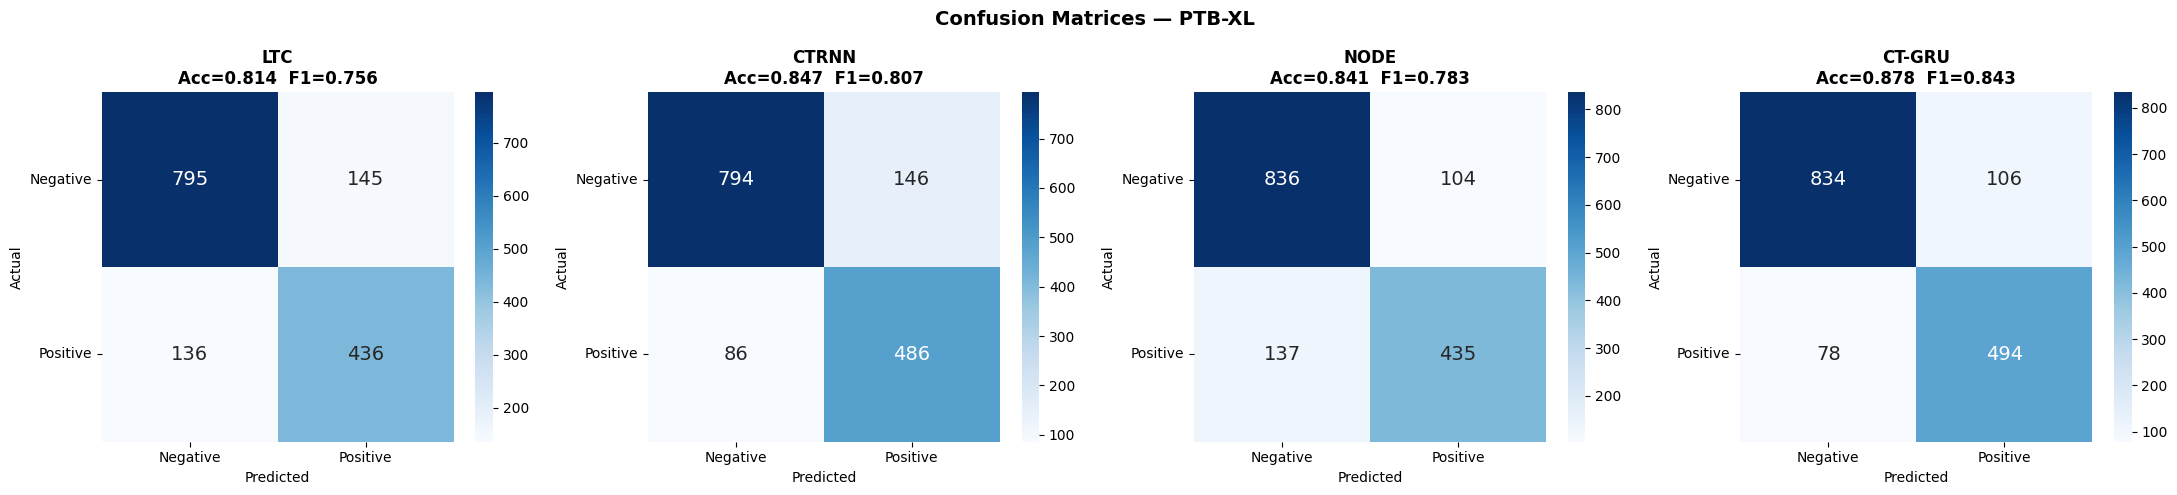

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle("Confusion Matrices — PTB-XL", fontsize=14, fontweight='bold')
results_all = [("LTC",ltc_lbls,ltc_preds),("CTRNN",ctrnn_lbls,ctrnn_preds),
               ("NODE",node_lbls,node_preds),("CT-GRU",ctgru_lbls,ctgru_preds)]
for ax,(name,lbls,preds) in zip(axes,results_all):
    cm = confusion_matrix(lbls, preds, labels=[0,1])
    tn,fp,fn,tp = cm.ravel()
    acc = (tn+tp)/(tn+fp+fn+tp+1e-8); f1 = 2*tp/(2*tp+fp+fn+1e-8)
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',cbar=True,ax=ax,annot_kws={"size":14})
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(f"{name}\nAcc={acc:.3f}  F1={f1:.3f}",fontsize=12,fontweight='bold')
    ax.set_xticks([0.5,1.5]); ax.set_xticklabels(["Negative","Positive"])
    ax.set_yticks([0.5,1.5]); ax.set_yticklabels(["Negative","Positive"],rotation=0)
plt.tight_layout()
plt.savefig("cm_ptbxl_all.png", dpi=150, bbox_inches='tight')
plt.show()


## Summary Table — All 12 Metrics

In [14]:
import pandas as pd
summary = pd.DataFrame({
    "LTC":ltc_metrics,"CTRNN":ctrnn_metrics,
    "NODE":node_metrics,"CT-GRU":ctgru_metrics,
}).T.round(4)
print("\n=== 12-Metric Summary — PTB-XL ===")
print(summary.to_string())
summary



=== 12-Metric Summary — PTB-XL ===
        Accuracy  Sensitivity  Specificity  Precision     NPV      F1      F2  BalancedAcc     MCC   Kappa  ROC_AUC  PR_AUC
LTC       0.8142       0.7622       0.8457     0.7504  0.8539  0.7563  0.7598       0.8040  0.6062  0.6061   0.8696  0.8472
CTRNN     0.8466       0.8497       0.8447     0.7690  0.9023  0.8073  0.8322       0.8472  0.6827  0.6804   0.9199  0.9092
NODE      0.8406       0.7605       0.8894     0.8071  0.8592  0.7831  0.7694       0.8249  0.6580  0.6573   0.8936  0.8845
CT-GRU    0.8783       0.8636       0.8872     0.8233  0.9145  0.8430  0.8553       0.8754  0.7443  0.7437   0.9413  0.9272


,Accuracy,Sensitivity,Specificity,Precision,NPV,F1,F2,BalancedAcc,MCC,Kappa,ROC_AUC,PR_AUC
LTC,0.8142,0.7622,0.8457,0.7504,0.8539,0.7563,0.7598,0.8040,0.6062,0.6061,0.8696,0.8472
CTRNN,0.8466,0.8497,0.8447,0.7690,0.9023,0.8073,0.8322,0.8472,0.6827,0.6804,0.9199,0.9092
NODE,0.8406,0.7605,0.8894,0.8071,0.8592,0.7831,0.7694,0.8249,0.6580,0.6573,0.8936,0.8845
CT-GRU,0.8783,0.8636,0.8872,0.8233,0.9145,0.8430,0.8553,0.8754,0.7443,0.7437,0.9413,0.9272
